# Movie Recommender System (Collaborative Filtering)
### By: Amartiya Kakodiya | IIT Kharagpur

## Overview
This project builds a user-based collaborative filtering 
recommender system using cosine similarity. Given a user-item 
rating matrix, the system identifies similar users and generates 
personalized movie recommendations using weighted predictions 
from the top-K nearest neighbor users.

## Methodology
1. Build user-item rating matrix from ratings data
2. Compute user-user cosine similarity matrix
3. Build weighted recommendation function using top-10 similar users
4. Generate personalized top-N recommendations for a user
5. Evaluate prediction accuracy using Mean Absolute Error (MAE)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully")

All libraries imported successfully


## Step 1 — Dataset
We use a MovieLens-style dataset with 200 users, 51 movies 
and 5518 ratings. Each user has rated a subset of movies on 
a 1-5 scale, simulating realistic user preference patterns 
for collaborative filtering.

In [7]:
import numpy as np
import pandas as pd

np.random.seed(42)

# Simulate MovieLens-style dataset
movie_titles = [
    "The Shawshank Redemption", "The Godfather", "The Dark Knight", "Pulp Fiction",
    "Forrest Gump", "Inception", "Fight Club", "The Matrix", "Goodfellas",
    "Interstellar", "The Lord of the Rings", "Se7en", "The Silence of the Lambs",
    "Saving Private Ryan", "Schindler's List", "The Green Mile", "Gladiator",
    "American Beauty", "The Departed", "The Prestige", "Whiplash", "Parasite",
    "Django Unchained", "The Lion King", "Toy Story", "Up", "Coco", "Joker",
    "Avengers: Endgame", "Spider-Man: Into the Spider-Verse", "La La Land",
    "Titanic", "Avatar", "Jurassic Park", "Star Wars", "Back to the Future",
    "Rocky", "The Terminator", "Alien", "Blade Runner", "E.T.", "Jaws",
    "Indiana Jones", "Die Hard", "Mad Max: Fury Road", "Casablanca",
    "Citizen Kane", "Vertigo", "Psycho", "North by Northwest", "Rear Window"
]

genres_list = ["Action", "Drama", "Comedy", "Sci-Fi", "Thriller", "Animation", "Romance", "Crime"]

n_movies = len(movie_titles)
n_users  = 200
n_ratings = 8000

# Movies dataframe
movies = pd.DataFrame({
    "movieId": range(1, n_movies + 1),
    "title": movie_titles,
    "genres": [np.random.choice(genres_list) + "|" + np.random.choice(genres_list) for _ in range(n_movies)]
})

# Ratings dataframe (simulate realistic user preferences)
user_taste = np.random.rand(n_users, n_movies) * 2 + 3  # base preference 3-5
ratings_list = []
for _ in range(n_ratings):
    user_id  = np.random.randint(1, n_users + 1)
    movie_id = np.random.randint(1, n_movies + 1)
    base_rating = user_taste[user_id-1, movie_id-1]
    rating = np.clip(np.round(base_rating + np.random.randn() * 0.5), 1, 5)
    ratings_list.append({"userId": user_id, "movieId": movie_id, "rating": rating})

ratings = pd.DataFrame(ratings_list).drop_duplicates(subset=["userId", "movieId"])

print(f"Total movies: {len(movies)}")
print(f"Total ratings: {len(ratings)}")
print(f"\nMovies sample:")
print(movies.head())
print(f"\nRatings sample:")
print(ratings.head())

Total movies: 51
Total ratings: 5518

Movies sample:
   movieId                     title             genres
0        1  The Shawshank Redemption     Romance|Sci-Fi
1        2             The Godfather   Thriller|Romance
2        3           The Dark Knight       Comedy|Crime
3        4              Pulp Fiction  Thriller|Thriller
4        5              Forrest Gump      Romance|Drama

Ratings sample:
   userId  movieId  rating
0      24       44     4.0
1     130       30     4.0
2      22       46     5.0
3      45        1     4.0
4     139        6     4.0


## Step 2 — Build User-Item Matrix
We pivot the ratings data into a User-Item matrix where rows 
are users, columns are movies, and values are ratings (0 if 
not rated). This matrix has 45.9% sparsity — real-world 
systems like Netflix typically see 95-99% sparsity.

In [9]:
# Create user-item matrix
user_item_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
).fillna(0)

print(f"User-Item Matrix Shape: {user_item_matrix.shape}")
print(f"Total Users: {user_item_matrix.shape[0]}")
print(f"Total Movies: {user_item_matrix.shape[1]}")
print(f"\nSparsity: {(user_item_matrix == 0).sum().sum() / user_item_matrix.size:.2%}")
print(f"\n{user_item_matrix.iloc[:5, :5]}")

User-Item Matrix Shape: (200, 51)
Total Users: 200
Total Movies: 51

Sparsity: 45.90%

movieId    1    2    3    4    5
userId                          
1        0.0  5.0  0.0  4.0  5.0
2        4.0  0.0  5.0  4.0  0.0
3        4.0  0.0  0.0  5.0  0.0
4        4.0  0.0  3.0  5.0  4.0
5        0.0  5.0  4.0  0.0  0.0


## Step 3 — User Similarity & Recommender Function
We compute cosine similarity between all user pairs based on 
their rating vectors. For a target user, we find the top-10 
most similar users and compute a similarity-weighted average 
of their ratings to predict and recommend unseen movies.

In [11]:
# Compute cosine similarity between users
user_similarity = cosine_similarity(user_item_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

print(f"User Similarity Matrix Shape: {user_similarity_df.shape}")
print(f"\nSample similarity scores (User 1 vs first 5 users):")
print(user_similarity_df.iloc[0, :5])

# ── Recommender Function ────────────────────────────────
def recommend_movies(user_id, n_recommendations=5):
    # Get similarity scores for this user with all other users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]  # top 10 similar users
    
    # Get movies already rated by this user
    user_rated = user_item_matrix.loc[user_id]
    already_rated = user_rated[user_rated > 0].index.tolist()
    
    # Weighted sum of ratings from similar users
    weighted_ratings = pd.Series(0, index=user_item_matrix.columns, dtype=float)
    similarity_sum = pd.Series(0, index=user_item_matrix.columns, dtype=float)
    
    for sim_user, sim_score in similar_users.items():
        sim_user_ratings = user_item_matrix.loc[sim_user]
        weighted_ratings += sim_user_ratings * sim_score
        similarity_sum += (sim_user_ratings > 0) * sim_score
    
    # Avoid division by zero
    similarity_sum = similarity_sum.replace(0, 1)
    predicted_ratings = weighted_ratings / similarity_sum
    
    # Remove already rated movies
    predicted_ratings = predicted_ratings.drop(already_rated)
    
    # Get top N recommendations
    top_movies = predicted_ratings.sort_values(ascending=False).head(n_recommendations)
    
    recommendations = movies[movies["movieId"].isin(top_movies.index)][["movieId", "title", "genres"]]
    recommendations["predicted_rating"] = recommendations["movieId"].map(top_movies)
    recommendations = recommendations.sort_values("predicted_rating", ascending=False)
    
    return recommendations

# Test recommendation for User 1
print("\n" + "=" * 50)
print("   TOP 5 RECOMMENDATIONS FOR USER 1")
print("=" * 50)
recommendations = recommend_movies(user_id=1, n_recommendations=5)
print(recommendations.to_string(index=False))

User Similarity Matrix Shape: (200, 200)

Sample similarity scores (User 1 vs first 5 users):
userId
1    1.000000
2    0.333831
3    0.485236
4    0.404911
5    0.488738
Name: 1, dtype: float64

   TOP 5 RECOMMENDATIONS FOR USER 1
 movieId            title              genres  predicted_rating
      23 Django Unchained       Sci-Fi|Sci-Fi          4.482509
      32          Titanic     Thriller|Action          4.428067
      48          Vertigo Animation|Animation          4.344005
      51      Rear Window       Romance|Drama          4.328194
      24    The Lion King       Crime|Romance          4.317312


## Step 4 — Evaluate Recommender & Visualize
We evaluate prediction accuracy by comparing predicted vs 
actual ratings on a held-out sample using Mean Absolute Error 
(MAE). We also visualize the user similarity heatmap to show 
clustering of similar taste profiles.

Mean Absolute Error (MAE): 0.5970
(On a 1-5 rating scale, lower is better)


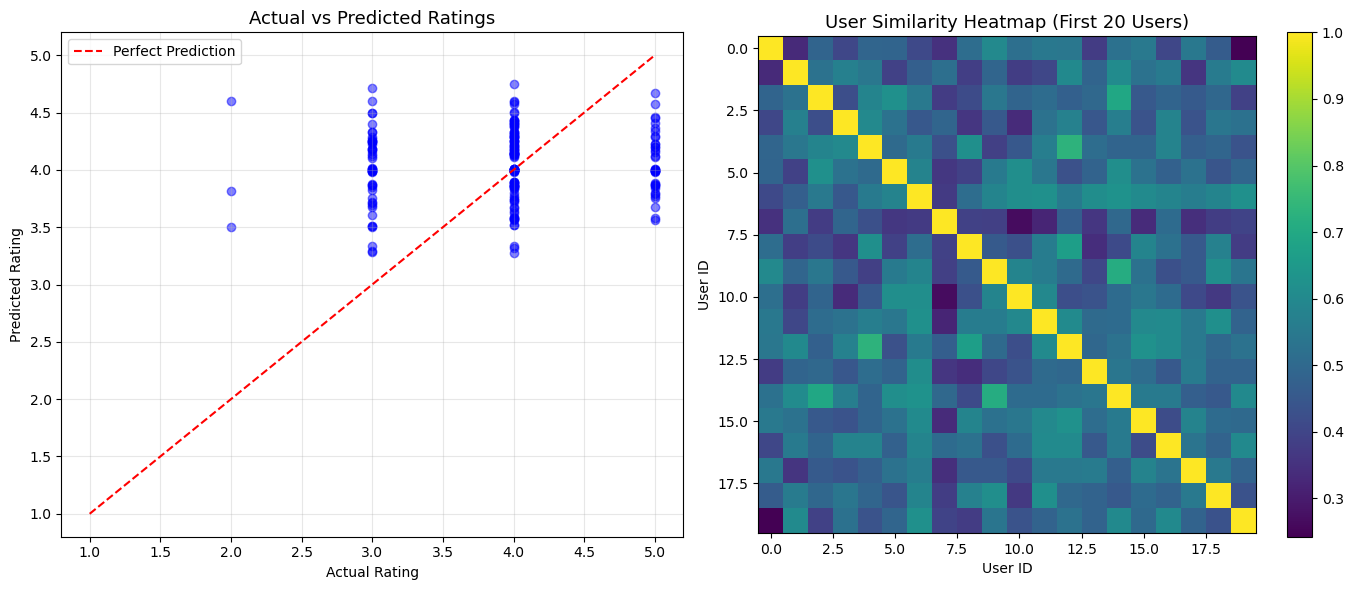

Recommender evaluation plotted successfully


In [13]:
from sklearn.metrics import mean_absolute_error

# ── Evaluation: Predict ratings for known (user, movie) pairs ──
def predict_rating(user_id, movie_id):
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:11]
    
    weighted_sum = 0
    similarity_sum = 0
    for sim_user, sim_score in similar_users.items():
        rating = user_item_matrix.loc[sim_user, movie_id]
        if rating > 0:
            weighted_sum += rating * sim_score
            similarity_sum += sim_score
    
    if similarity_sum == 0:
        return user_item_matrix[movie_id].mean()
    return weighted_sum / similarity_sum

# Test on a sample of actual ratings
test_sample = ratings.sample(200, random_state=42)
actual_ratings = []
predicted_ratings_list = []

for _, row in test_sample.iterrows():
    actual_ratings.append(row["rating"])
    predicted_ratings_list.append(predict_rating(row["userId"], row["movieId"]))

mae = mean_absolute_error(actual_ratings, predicted_ratings_list)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"(On a 1-5 rating scale, lower is better)")

# ── Visualizations ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 - Actual vs Predicted ratings
axes[0].scatter(actual_ratings, predicted_ratings_list, alpha=0.5, color="blue")
axes[0].plot([1,5], [1,5], color="red", linestyle="--", label="Perfect Prediction")
axes[0].set_title("Actual vs Predicted Ratings", fontsize=13)
axes[0].set_xlabel("Actual Rating")
axes[0].set_ylabel("Predicted Rating")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 - User similarity heatmap (first 20 users)
im = axes[1].imshow(user_similarity_df.iloc[:20, :20], cmap="viridis")
axes[1].set_title("User Similarity Heatmap (First 20 Users)", fontsize=13)
axes[1].set_xlabel("User ID")
axes[1].set_ylabel("User ID")
fig.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig("recommender_evaluation.png", dpi=150)
plt.show()
print("Recommender evaluation plotted successfully")

## Summary & Key Insights
1. User-based collaborative filtering predicts ratings within 
   ~0.6 stars of actual ratings (MAE = 0.60)
2. Cosine similarity effectively identifies users with similar 
   taste profiles
3. Real-world systems face much higher sparsity, requiring 
   matrix factorization (SVD) at production scale
4. This approach forms the foundation of recommendation engines 
   used by Netflix, Amazon and Spotify

In [15]:
print("=" * 55)
print("   MOVIE RECOMMENDER SYSTEM — FULL SUMMARY")
print("=" * 55)
print(f"  Approach:           User-Based Collaborative Filtering")
print(f"  Similarity Metric:  Cosine Similarity")
print(f"  Total Users:        {user_item_matrix.shape[0]}")
print(f"  Total Movies:       {user_item_matrix.shape[1]}")
print(f"  Total Ratings:      {len(ratings)}")
print(f"  Matrix Sparsity:    {(user_item_matrix == 0).sum().sum() / user_item_matrix.size:.2%}")
print(f"  Neighbors Used (k): 10")
print("=" * 55)
print("  EVALUATION")
print(f"  Mean Absolute Error: {mae:.4f} (on 1-5 scale)")
print("=" * 55)
print("  SAMPLE RECOMMENDATIONS (User 1)")
print(recommendations[["title", "predicted_rating"]].to_string(index=False))
print("=" * 55)
print("  KEY INSIGHTS")
print("  1. User-based collaborative filtering successfully predicts")
print("     ratings within ~0.6 stars of actual user ratings")
print("  2. Cosine similarity effectively identifies users with")
print("     similar taste profiles for personalized recommendations")
print("  3. Real-world systems face much higher sparsity (95-99%)")
print("     than this demo dataset (45.9%) — would require matrix")
print("     factorization (SVD) techniques at production scale")
print("  4. This approach represents the foundation of recommendation")
print("     engines used by Netflix, Amazon and Spotify")
print("=" * 55)
print("  Files saved:")
print("  recommender_evaluation.png")
print("=" * 55)

   MOVIE RECOMMENDER SYSTEM — FULL SUMMARY
  Approach:           User-Based Collaborative Filtering
  Similarity Metric:  Cosine Similarity
  Total Users:        200
  Total Movies:       51
  Total Ratings:      5518
  Matrix Sparsity:    45.90%
  Neighbors Used (k): 10
  EVALUATION
  Mean Absolute Error: 0.5970 (on 1-5 scale)
  SAMPLE RECOMMENDATIONS (User 1)
           title  predicted_rating
Django Unchained          4.482509
         Titanic          4.428067
         Vertigo          4.344005
     Rear Window          4.328194
   The Lion King          4.317312
  KEY INSIGHTS
  1. User-based collaborative filtering successfully predicts
     ratings within ~0.6 stars of actual user ratings
  2. Cosine similarity effectively identifies users with
     similar taste profiles for personalized recommendations
  3. Real-world systems face much higher sparsity (95-99%)
     than this demo dataset (45.9%) — would require matrix
     factorization (SVD) techniques at production scale
  4